In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
train_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
train_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


Linear Regression

In [ ]:
#Target variable: median_house_value
X_train = train_df.drop('median_house_value', axis=1)
y_train = train_df['median_house_value']

X_test = test_df.drop('median_house_value', axis=1)
y_test = test_df['median_house_value']

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = linear_model.predict(X_test_scaled)

In [ ]:
#Linear regression model evaluation

mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Mean Squared Error: ", mse)
print("R-squared score: ", r2)

Mean Squared Error:  4867205486.928867
R-squared score:  0.6195057678311999


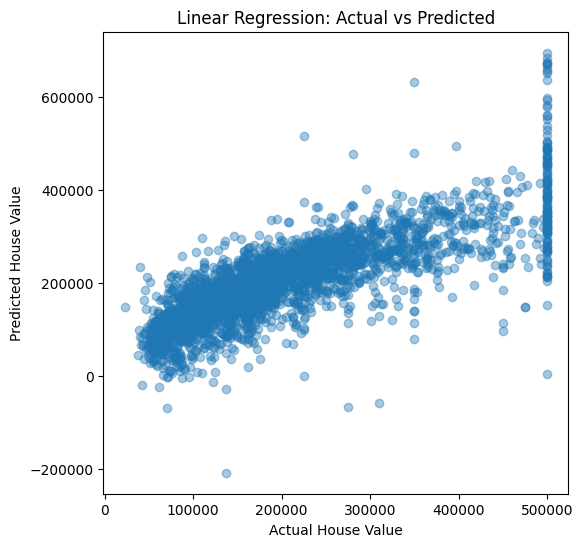

In [ ]:
#Actual vs Predicted Visualization

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Logistic Regression

In [ ]:
median_price = train_df['median_house_value'].median()

train_df['price_category'] = (train_df['median_house_value'] > median_price).astype(int)
test_df['price_category'] = (test_df['median_house_value'] > median_price).astype(int)

In [ ]:
X_train_log = train_df.drop(['median_house_value', 'price_category'], axis=1)
y_train_log = train_df['price_category']

X_test_log = test_df.drop(['median_house_value', 'price_category'], axis=1)
y_test_log = test_df['price_category']

In [ ]:
scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_log_scaled, y_train_log)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = logistic_model.predict(X_test_log_scaled)

In [ ]:
accuracy = accuracy_score(y_test_log, y_pred_log)
print("Accuracy: ", accuracy)

Accuracy:  0.837


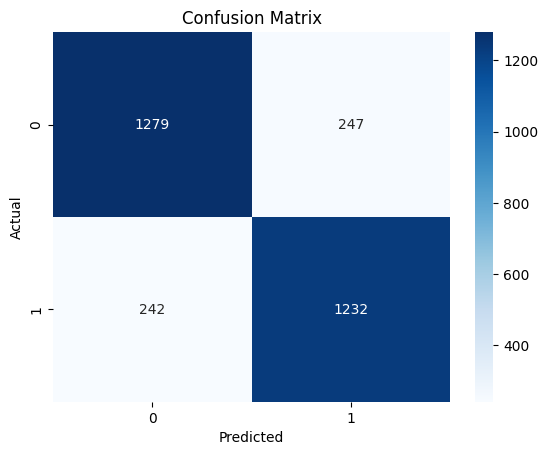

In [ ]:
cm = confusion_matrix(y_test_log, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test_log, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1526
           1       0.83      0.84      0.83      1474

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000

